In [ ]:
from pyvela import SPNTA, pyvela_plot
import pocomc as poco

from collections import namedtuple

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [2]:
spnta = SPNTA("NGC6440E.par", "NGC6440E.tim")

WARNING  (pint.logging                  ): /home/abhimanyu/Work/Vela.jl/pyvela/pyvela/spnta.py:213 UserWarning: The log-prior is non-finite at the default parameter values. This is probably a mistake in the prior definition. Please check this.
WARNING  (pint.logging                  ): /home/abhimanyu/Work/Vela.jl/pyvela/pyvela/spnta.py:221 UserWarning: Log-prior is non-finite at the default value of EQUAD1.


In [3]:
# Recast the prior distribution in a way pocoMC understands.
prior = namedtuple("PocoPrior", "dim bounds logpdf rvs")(
    spnta.ndim,
    spnta.prior_bounds,
    spnta.lnprior_vectorized,
    spnta.draw_from_prior,
)

In [4]:
sampler = poco.Sampler(
    prior=prior,
    likelihood=spnta.lnlike_vectorized,
    vectorize=True,
    random_state=0
)

In [5]:
sampler.run()

Iter: 50it [03:04,  3.69s/it, beta=1, calls=91904, ESS=3929, logZ=596, logP=679, acc=0.705, steps=4, eff=1]             


In [6]:
samples_raw, logl, logp = sampler.posterior(resample=True)

In [ ]:
outdir = "NGC6440E_out"

In [ ]:
spnta.save_pre_analysis_summary(outdir)
spnta.save_results(outdir, samples_raw, logZ=sampler.evidence())

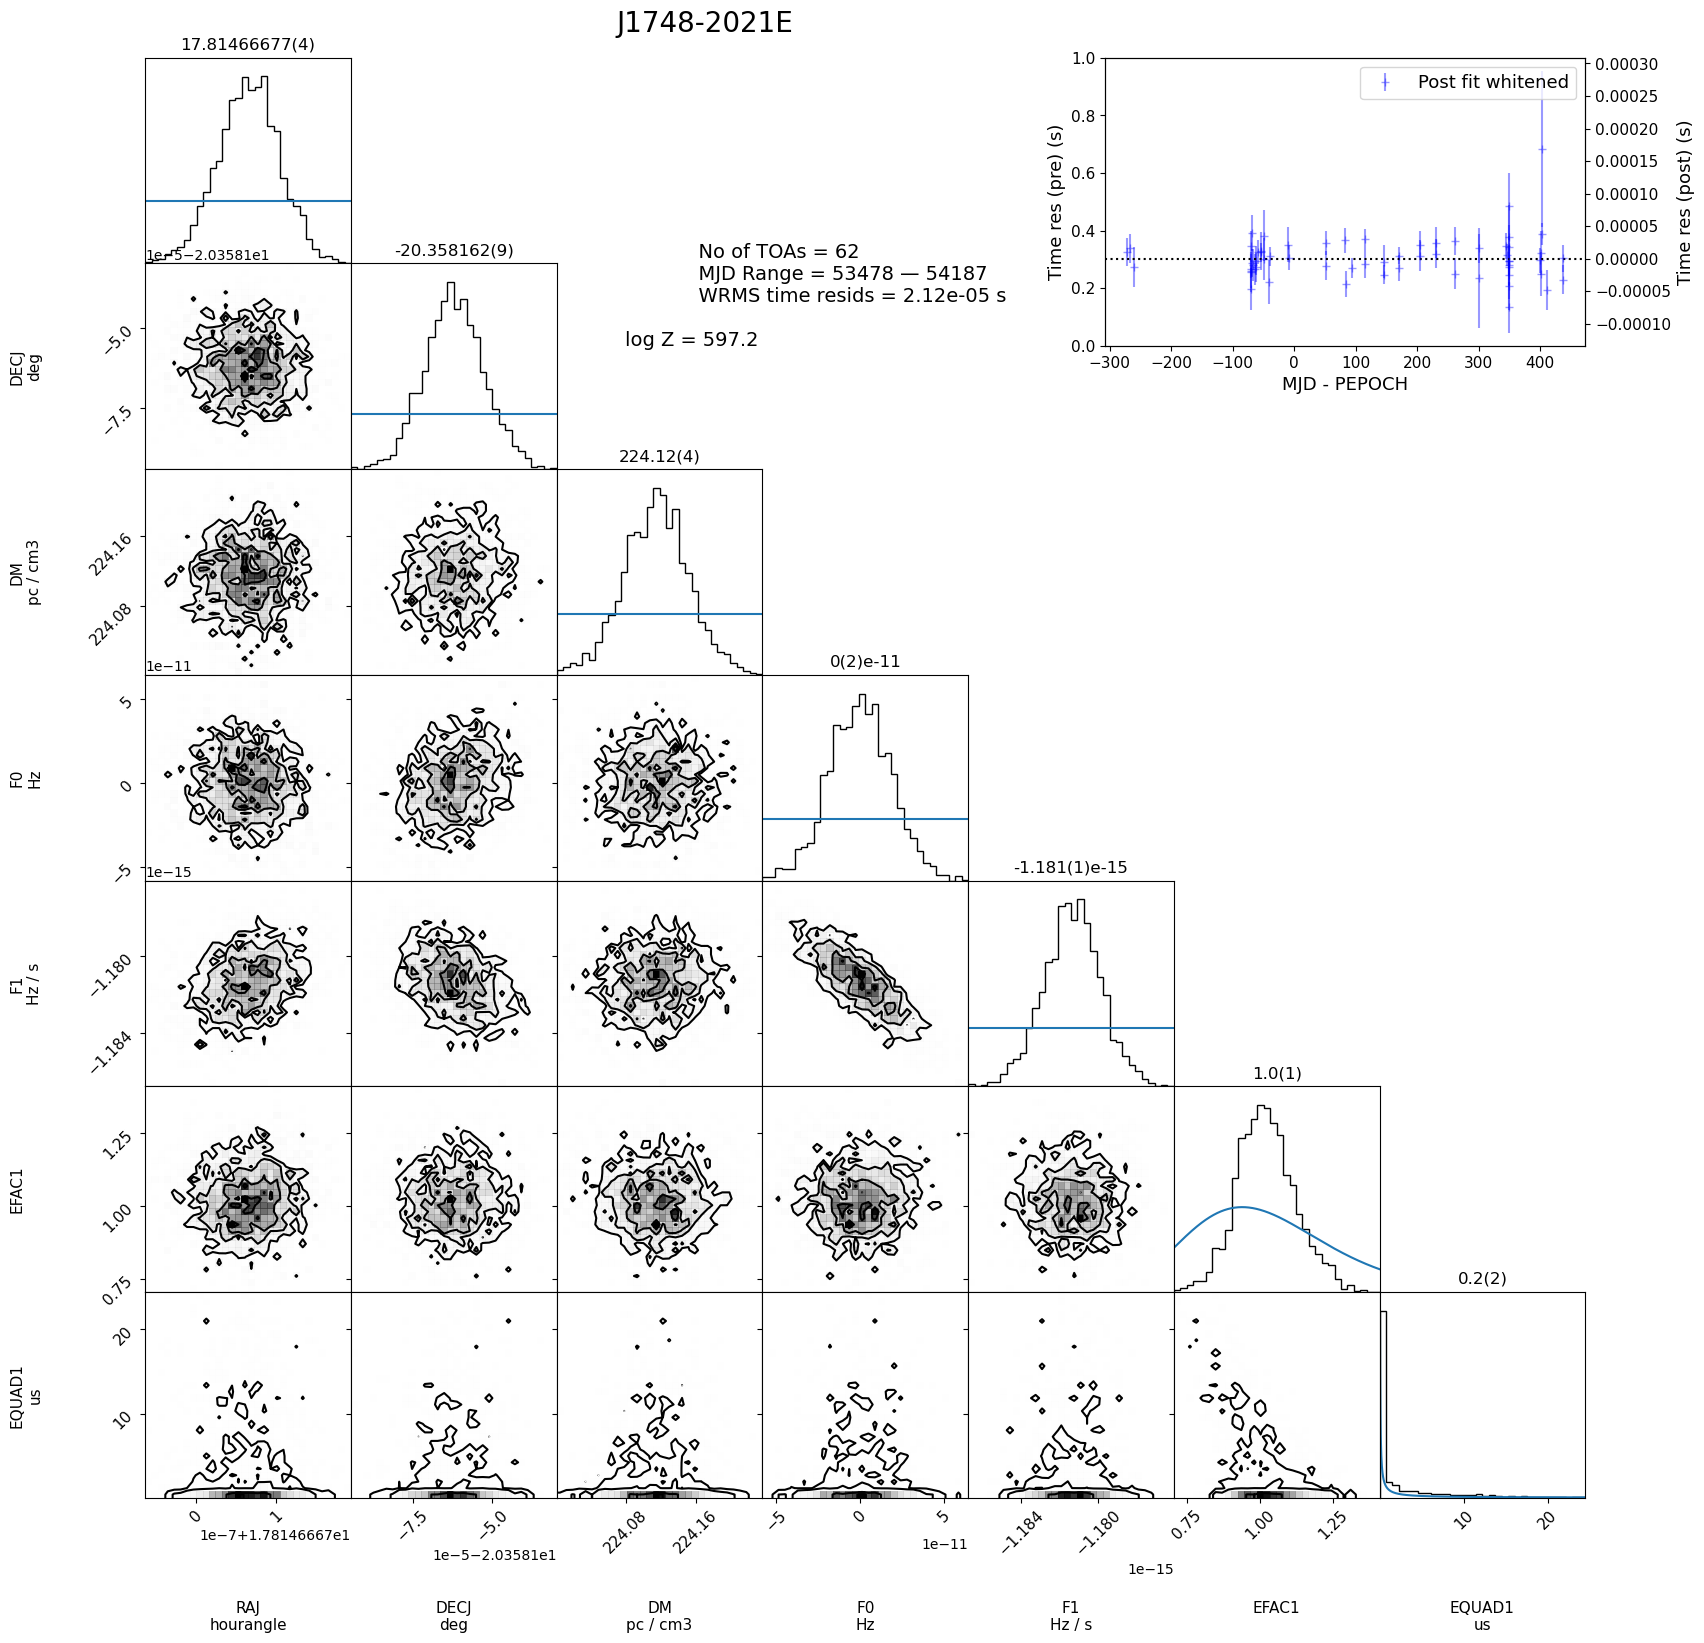

In [ ]:
pyvela_plot.plot(outdir, plot_priors=True)